### Load all simulation complexes

Load all simulation complexes.


In [1]:
import os
import glob
from tqdm.notebook import tqdm
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

homedir = os.getenv("HOME")
gdrive_mnt = "mnt/gdrive"
datadir = 'data/GROMACS'
datadir_path = os.path.join(homedir, gdrive_mnt, datadir)

# Find all simulation directories starting with cuedc2_
simulation_dirs = [
    os.path.join(datadir_path, entry)
    for entry in sorted(os.listdir(datadir_path))
    if entry.startswith("cuedc2_") and os.path.isdir(os.path.join(datadir_path, entry))
]


In [2]:
simulation_dirs

['/home/daneel/mnt/gdrive/data/GROMACS/cuedc2_dig',
 '/home/daneel/mnt/gdrive/data/GROMACS/cuedc2_erg',
 '/home/daneel/mnt/gdrive/data/GROMACS/cuedc2_mid',
 '/home/daneel/mnt/gdrive/data/GROMACS/cuedc2_par',
 '/home/daneel/mnt/gdrive/data/GROMACS/cuedc2_rif']

Prepare protlig tpr selections for each complex (unless it already exists from old PP)

Now, prepare MDAnalysis universes for each complex

In [6]:
complexes = {}

for dirpath in tqdm(simulation_dirs):
    complex_name = os.path.basename(dirpath)
    
    # Recursively find traj_dry.tpr and *_compact_compact.xtc
    tpr_files = glob.glob(os.path.join(dirpath, "**", "traj_dry.tpr"), recursive=True)
    xtc_files = sorted(glob.glob(os.path.join(dirpath, "**", "*_compact_compact.xtc"), recursive=True))
    
    if not tpr_files:
        print(f"Skipping {complex_name}: 'traj_dry.tpr' not found")
        continue
    if not xtc_files:
        print(f"Skipping {complex_name}: '*_compact_compact.xtc' not found")
        continue
        
    complexes[complex_name] = {
        "tpr": tpr_files[0],
        "xtc": xtc_files[0] if len(xtc_files) == 1 else xtc_files,
    }
    print(f"Loaded {complex_name}: {len(xtc_files)} trajectory file(s)")


  0%|          | 0/5 [00:00<?, ?it/s]

Loaded cuedc2_dig: 1 trajectory file(s)
Loaded cuedc2_erg: 1 trajectory file(s)
Loaded cuedc2_mid: 1 trajectory file(s)
Loaded cuedc2_par: 1 trajectory file(s)
Loaded cuedc2_rif: 1 trajectory file(s)


In [7]:
complexes

{'cuedc2_dig': {'tpr': '/home/daneel/mnt/gdrive/data/GROMACS/cuedc2_dig/prod/traj_dry.tpr',
  'xtc': '/home/daneel/mnt/gdrive/data/GROMACS/cuedc2_dig/prod/prod_cuedc2_dig_compact_compact.xtc'},
 'cuedc2_erg': {'tpr': '/home/daneel/mnt/gdrive/data/GROMACS/cuedc2_erg/prod/traj_dry.tpr',
  'xtc': '/home/daneel/mnt/gdrive/data/GROMACS/cuedc2_erg/prod/prod_cuedc2_erg_compact_compact.xtc'},
 'cuedc2_mid': {'tpr': '/home/daneel/mnt/gdrive/data/GROMACS/cuedc2_mid/prod/traj_dry.tpr',
  'xtc': '/home/daneel/mnt/gdrive/data/GROMACS/cuedc2_mid/prod/prod_complex_cuedc2_corrected_mid_compact_compact.xtc'},
 'cuedc2_par': {'tpr': '/home/daneel/mnt/gdrive/data/GROMACS/cuedc2_par/prod/traj_dry.tpr',
  'xtc': '/home/daneel/mnt/gdrive/data/GROMACS/cuedc2_par/prod/prod_complex_cuedc2_corrected_par_compact_compact.xtc'},
 'cuedc2_rif': {'tpr': '/home/daneel/mnt/gdrive/data/GROMACS/cuedc2_rif/prod/traj_dry.tpr',
  'xtc': '/home/daneel/mnt/gdrive/data/GROMACS/cuedc2_rif/prod/prod_complex_cuedc2_corrected_rif

### Calculate all RMSD values and load in a dataframe

Using nproc=5


  0%|          | 0/5 [00:00<?, ?it/s]

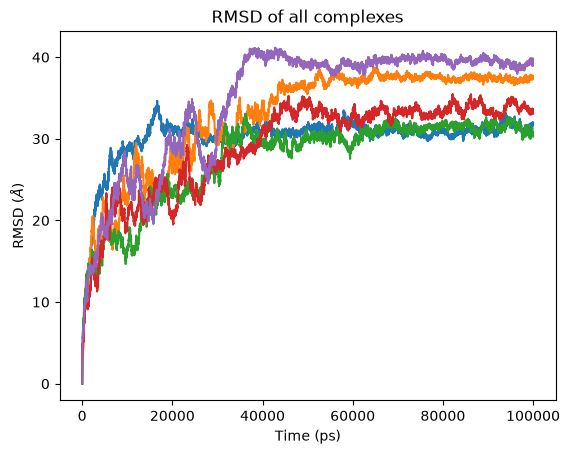

In [8]:
from multiprocessing import Pool, cpu_count
import os
import pandas as pd

def _compute_rmsd_task(args):
    complexname, topol_path, traj_path = args
    import MDAnalysis as mda
    from MDAnalysis.analysis import rms
    u = mda.Universe(topol_path, traj_path)
    R = rms.RMSD(u, u, select='backbone', ref_frame=0)
    R.run(verbose=False)
    times = R.results.rmsd[:, 1]
    rmsd = R.results.rmsd[:, 2]
    return complexname, times, rmsd

# Build list of (name, topol_path, traj_path) so worker processes don't need non-picklable Universe objects
tasks = [
    (complex_name, data["tpr"], data["xtc"])
    for complex_name, data in complexes.items()
]

rmsd_df = None
# If SLURM_CPUS_PER_TASK is set, use it (fall back to previously computed nproc)
slurm_cpus = 5 #os.environ.get('SLURM_CPUS_PER_TASK')
if slurm_cpus:
    try:
        nproc_env = int(slurm_cpus)
        if nproc_env > 0:
            nproc = nproc_env
    except ValueError:
        pass

# Ensure we don't request more processes than logical CPUs
nproc = max(1, min(nproc, cpu_count()))

print(f"Using nproc={nproc}")
with Pool(processes=nproc) as pool:
    for complexname, times, rmsd in tqdm(pool.imap_unordered(_compute_rmsd_task, tasks), total=len(tasks)):
        if rmsd_df is None:
            rmsd_df = pd.DataFrame({'Time': times})
        rmsd_df[complexname] = rmsd

# Prepare and display the plot.
rmsd_df.set_index('Time', inplace=True)
rmsd_df.plot(legend=False)
plt.xlabel('Time (ps)')
plt.ylabel(r'RMSD ($\AA$)')
plt.title('RMSD of all complexes')
#plt.legend(title='Complex')
plt.show()


In [9]:
rmsd_df.head()

,cuedc2_rif,cuedc2_par,cuedc2_dig,cuedc2_mid,cuedc2_erg
Time,,,,,
0.0,0.000001,0.000002,0.000001,0.000001,0.000002
10.0,1.695747,1.390080,2.011231,1.948114,1.544373
20.0,2.583786,1.834889,2.730318,2.135650,2.266095
30.0,3.198093,2.309955,3.226793,2.250203,2.951368
40.0,3.798505,2.661251,3.462272,2.524410,3.145677


### Calculate all RMSF and load in a dictionary

In [ ]:
import pandas as pd
import MDAnalysis as mda
from MDAnalysis.analysis import rms
import numpy as _np

# Build list of (name, topol_path, traj_path) so worker processes don't need non-picklable Universe objects
tasks = [
    (complex_name, data["tpr"], data["xtc"])
    for complex_name, data in complexes.items()
]

# worker (override previous broken definition)
def _compute_rmsf_task(args):
    complexname, topol_path, traj_path = args

    u = mda.Universe(topol_path, traj_path)
    sel = u.select_atoms('backbone and name CA')
    R = rms.RMSF(sel).run(verbose=False)
    resids = _np.array(sel.resids)
    rmsf = _np.array(R.results.rmsf)
    return complexname, resids, rmsf

# run in parallel and collect results
rmsf_dict = {}
with Pool(processes=nproc) as p:
    for complexname, resids, rmsf in tqdm(p.imap_unordered(_compute_rmsf_task, tasks), total=len(tasks)):
        rmsf_dict[f'{complexname}_resid'] = resids
        rmsf_dict[f'{complexname}_rmsf'] = rmsf

rmsf_df = pd.DataFrame(rmsf_dict)

  0%|          | 0/5 [00:00<?, ?it/s]

### Calculate all Radii of Gyration and load in a dataframe 

  0%|          | 0/5 [00:00<?, ?it/s]

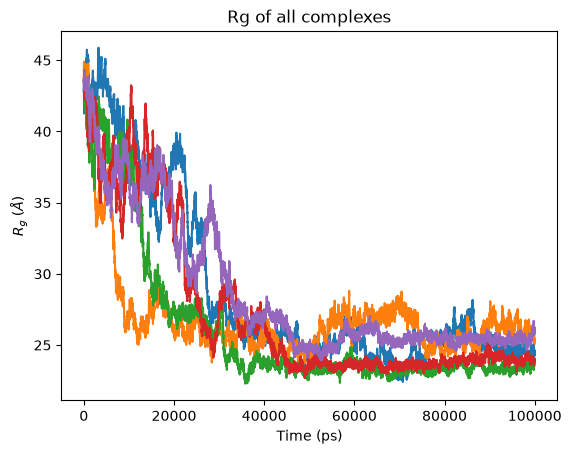

In [11]:
import pandas as pd
from MDAnalysis.analysis import rms
import MDAnalysis as mda
import numpy as _np
# Build list of (name, topol_path, traj_path) so worker processes don't need non-picklable Universe objects
rg_tasks = [
    (complex_name, data["tpr"], data["xtc"])
    for complex_name, data in complexes.items()
]

def _compute_rg_task(args):
    complexname, topol_path, traj_path = args
    u = mda.Universe(topol_path, traj_path)
    group = u.select_atoms('protein')
    times = []
    rg = []
    for ts in u.trajectory:
        times.append(ts.time)
        rg.append(group.radius_of_gyration())
    return complexname, _np.array(times), _np.array(rg)

rg_df = None
with Pool(processes=nproc) as pool:
    for complexname, times_arr, rg_arr in tqdm(pool.imap_unordered(_compute_rg_task, rg_tasks), total=len(rg_tasks)):
        if rg_df is None:
            rg_df = pd.DataFrame({'Time': times_arr})
        rg_df[complexname] = rg_arr

# Prepare and display the plot.
rg_df.set_index('Time', inplace=True)
rg_df.plot(legend=False)
plt.xlabel('Time (ps)')
plt.ylabel(r'$R_g\; (\AA)$')
plt.title('Rg of all complexes')
plt.show()

### Number of hydrogen bonds between protein and ligand

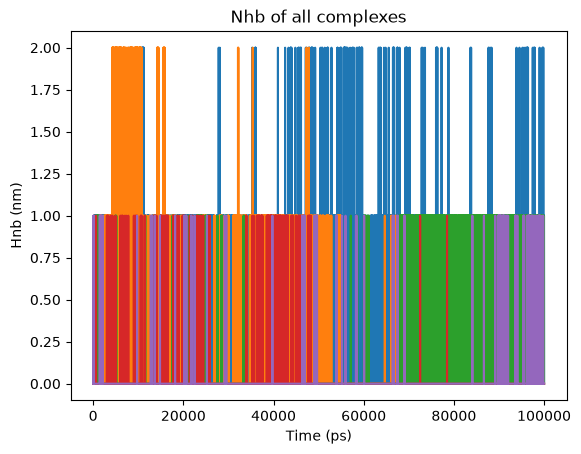

In [12]:
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
import numpy as np
import pandas as pd
import os
from multiprocessing import Pool
import numpy as _np
import MDAnalysis as mda
import warnings
import logging
warnings.filterwarnings("ignore")

logging.getLogger("MDAnalysis").setLevel(logging.ERROR)
logging.getLogger("matplotlib").setLevel(logging.ERROR)

# suppress numpy runtime warnings (e.g. divide by zero, invalid)
_np.seterr(all='ignore')
hb_dict = {}
# build tasks: (complexname, topol_path, traj_path)
# Build list of (name, topol_path, traj_path) so worker processes don't need non-picklable Universe objects
tasks_hb = [
    (complex_name, data["tpr"], data["xtc"])
    for complex_name, data in complexes.items()
]

# Temporarily prevent the serial loop below from executing by emptying complexes,
# we'll restore it after the parallel work.
_orig_complexes = complexes
complexes = {}

def _hba_worker(args):
    complexname, topol_path, traj_path = args

    u = mda.Universe(topol_path, traj_path)
    hbs = HBA(universe=u, update_selections=False)
    hbs.donors_sel = hbs.guess_donors("protein")
    hbs.hydrogens_sel = hbs.guess_hydrogens("protein")
    hbs.acceptors_sel = hbs.guess_acceptors("not protein")
    hbs.run(verbose=False)
    ligand_indices = u.select_atoms(hbs.acceptors_sel).indices

    hbs_reversed = HBA(universe=u, update_selections=False)
    hbs_reversed.donors_sel = hbs.guess_donors("not protein")
    hbs_reversed.hydrogens_sel = hbs.guess_hydrogens("not protein")
    hbs_reversed.acceptors_sel = hbs.guess_acceptors("protein")
    hbs_reversed.run(verbose=False)

    # filter to intermolecular bonds (protein <-> ligand)
    filtered = []
    for hb in hbs.results.hbonds:
        frame, donor_idx, hydrogen_idx, acceptor_idx, da_dist, da_angle = hb
        if (donor_idx not in ligand_indices and acceptor_idx in ligand_indices) or \
        (donor_idx in ligand_indices and acceptor_idx not in ligand_indices):
            filtered.append(hb)

    for hb in hbs_reversed.results.hbonds:
        frame, donor_idx, hydrogen_idx, acceptor_idx, da_dist, da_angle = hb
        if (donor_idx not in ligand_indices and acceptor_idx in ligand_indices) or \
        (donor_idx in ligand_indices and acceptor_idx not in ligand_indices):
            filtered.append(hb)

    filtered = np.array(filtered)

    # counts per frame (nhb)
    times = hbs.times
    if filtered.size == 0:
        nhb = _np.zeros_like(times, dtype=int)
    else:
        frames = filtered[:, 0].astype(int)
        nhb = _np.bincount(frames, minlength=len(times))[:len(times)]

    n_frames = hbs.n_frames

    # counts by (donor, hydrogen, acceptor)
    if filtered.size == 0:
        count_ids = _np.empty((0, 4), dtype=int)
    else:
        ids = filtered[:, 1:4].astype(int)
        uniq, counts = _np.unique(ids, axis=0, return_counts=True)
        count_ids = _np.hstack((uniq, counts.reshape(-1, 1))).astype(int)

    return complexname, {
        "hbonds": filtered,
        "times": times,
        "nhb": nhb,
        "n_frames": n_frames,
        "count_ids": count_ids,
    }

# Run workers and build hb_dict with lightweight stubs compatible with later code
hb_dict = {}
with Pool(processes=nproc) as pool:
    for complexname, data in pool.imap_unordered(_hba_worker, tasks_hb):
        class _HBAStub:
            def __init__(self, d):
                self.results = type("R", (), {})()
                self.results.hbonds = d["hbonds"]
                self.times = d["times"]
                self.n_frames = d["n_frames"]
                self._nhb = d["nhb"]
                self._count_ids = d["count_ids"]
            def count_by_time(self):
                return self._nhb
            def count_by_ids(self):
                return self._count_ids

        hb_dict[complexname] = _HBAStub(data)
# Restore complexes dictionary for potential later use
complexes = _orig_complexes
nhb_df = None
for complexname, hbs in hb_dict.items():
    times = hbs.times
    nhb = hbs.count_by_time()
    # For the first complex, initialize the DataFrame with the time column.
    if nhb_df is None:
        nhb_df = pd.DataFrame({'Time': times})
        
    # Add the RMSD values for the current complex to the DataFrame.
    nhb_df[complexname] = nhb
# Prepare and display the plot.
# Prepare and display the plot.
nhb_df.set_index('Time', inplace=True)
nhb_df.plot(legend=False)
plt.xlabel('Time (ps)')
plt.ylabel('Hnb (nm)')
plt.title('Nhb of all complexes')
plt.show()

In [13]:
from IPython.display import display

# find and show columns in nhb_df that contain only zeros
try:
    nhb_df  # ensure variable exists
except NameError:
    print("nhb_df is not defined in the current notebook.")
else:
    zero_cols = [c for c in nhb_df.columns if nhb_df[c].eq(0).all()]
    if not zero_cols:
        print("No columns contain only zeros.")
    else:
        print(f"Columns with all zeros ({len(zero_cols)}):")
        for name in zero_cols:
            print(" -", name)
        # display the data for those columns (useful in Jupyter)
        try:
            display(nhb_df[zero_cols])
        except Exception:
            print(nhb_df[zero_cols].head())

No columns contain only zeros.


In [23]:
hb_dict.items()

dict_items([('cuedc2_rif', <__main__._HBAStub object at 0x7dee360a0a70>), ('cuedc2_par', <__main__._HBAStub object at 0x7dee4572aff0>), ('cuedc2_mid', <__main__._HBAStub object at 0x7dee3609f200>), ('cuedc2_erg', <__main__._HBAStub object at 0x7dee35fa6780>), ('cuedc2_dig', <__main__._HBAStub object at 0x7dee35fb4fe0>)])

### Plot everything

### Hydrogen Bond occupancy statistics

In [27]:
from tqdm.notebook import tqdm
hb_details = {}

for complex, hb in tqdm(hb_dict.items()):
    u = mda.Universe(complexes[complex]['tpr'], complexes[complex]['xtc'])
    ligand_indices = u.select_atoms('not protein').indices
    ligand_names = u.select_atoms('not protein').resnames
    hbstats = hb.count_by_ids()
    # Only keep bonds with occupancy more than 0.1%
    hbstats_filtered = hbstats[hbstats[:, -1] / hb.n_frames > 0.001]
    bond_types = []
    for bond in hbstats_filtered:
        donor_idx, hydrogen_idx, acceptor_idx, occ = bond
        donor_atom = u.atoms[int(donor_idx)]
        hydrogen_atom = u.atoms[int(hydrogen_idx)]
        acceptor_atom = u.atoms[int(acceptor_idx)]
        # Check if the donor or acceptor is a ligand
        if donor_idx in ligand_indices and acceptor_idx not in ligand_indices:
            # Donor is a ligand, acceptor is not
            bond_type = f"({donor_atom.resname}){donor_atom.name}-H::{acceptor_atom.name}({acceptor_atom.resid}-{acceptor_atom.resname}) : {occ/hb.n_frames:.3f}"
        elif acceptor_idx in ligand_indices and donor_idx not in ligand_indices:
            # Acceptor is a ligand, donor is not
            bond_type = f"({donor_atom.resid}-{donor_atom.resname}){donor_atom.name}-H::{acceptor_atom.name}({acceptor_atom.resname}) : {occ/hb.n_frames:.3f}"
        else:
            # Both donor and acceptor are ligands
            continue
        bond_types.append(bond_type)
    
    hb_details[complex] = bond_types

  0%|          | 0/5 [00:00<?, ?it/s]

### Save the hydrogen bond data to a json file so you don't have to keep calculating it

In [29]:
import json

outpath = os.path.join(datapath, "hb_details.json")
with open(outpath, "w") as fh:
    json.dump(hb_details, fh, indent=2)
print(f"Saved hb_details to {outpath}")

Saved hb_details to /home/daneel/gitrepos/gromacs_sims/protein-cuedc2-ligands-sim/hb_details.json


### Export to csv for later use

In [ ]:
rmsd_df.to_csv('rmsd.csv', index=False)
rmsf_df.to_csv('rmsf.csv', index=False)
rg_df.to_csv('rg.csv', index=False)
nhb_df.to_csv('nhb.csv', index=False)

## Import and Plot everything

In [29]:
import json
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------------------------------------------
# 1. Direct File Imports
# -------------------------------------------------------------
rmsd_df = pd.read_csv("rmsd.csv")
rg_df = pd.read_csv("rg.csv")
rmsf_df = pd.read_csv("rmsf.csv")
nhb_df = pd.read_csv("nhb.csv")

with open("hb_details.json", "r") as f:
  hb_stats_data = json.load(f)

# -------------------------------------------------------------
# 2. Metadata (Alphabetical Order) & H-Bond Name Processing
# -------------------------------------------------------------
complex_order = [
    "cuedc2_dig",
    "cuedc2_erg",
    "cuedc2_mid",
    "cuedc2_par",
    "cuedc2_rif",
]
labels = {
    "cuedc2_dig": "CUEDC2-DIG",
    "cuedc2_erg": "CUEDC2-ERG",
    "cuedc2_mid": "CUEDC2-MID",
    "cuedc2_par": "CUEDC2-PAR",
    "cuedc2_rif": "CUEDC2-RIF",
}
colors = {
    "cuedc2_dig": "#9467bd",  # Purple
    "cuedc2_erg": "#d62728",  # Red
    "cuedc2_mid": "#2ca02c",  # Green
    "cuedc2_par": "#ff7f0e",  # Orange
    "cuedc2_rif": "#1f77b4",  # Blue
}

# Parse H-bonds: remove ligand residue name (e.g. "::O7(RIF)" -> "::O7")
# and sum occupancy for duplicate donor-acceptor interactions per complex
hb_records = []
for comp in complex_order:
  entries = hb_stats_data.get(comp, [])
  pair_dict = {}
  for entry in entries:
    pair, occ = entry.split(" : ")
    clean_name = re.sub(r"::([A-Za-z0-9]+)\([A-Za-z0-9]+\)", r"::\1", pair)
    clean_name = re.sub(r"\([A-Za-z0-9]+\)$", "", clean_name)
    occ_val = float(occ) * 100.0
    pair_dict[clean_name] = pair_dict.get(clean_name, 0.0) + occ_val
  for name, val in pair_dict.items():
    hb_records.append({"complex": comp, "bond": name, "occupancy": val})

df_hb_bars = pd.DataFrame(hb_records)
time_ns = np.linspace(0, 100, len(rmsd_df))

# -------------------------------------------------------------
# 3. Figure Layout (3 Panels)
# -------------------------------------------------------------
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# --- Panel A: RMSD (Left Axis) & Rg (Right Axis) over Time ---
ax1 = axes[0]
ax1_twin = ax1.twinx()
for c in complex_order:
  ax1.plot(
      time_ns,
      rmsd_df[c],
      color=colors[c],
      lw=1.6,
      alpha=0.9,
      label=f"{labels[c]} RMSD",
  )
  ax1_twin.plot(
      time_ns,
      rg_df[c],
      color=colors[c],
      ls="--",
      lw=1.2,
      alpha=0.45,
      label=fr"{labels[c]} $R_g$",
  )

ax1.set_title(
    r"A. Structural Stability (RMSD) \& Compactness ($R_g$) over Time",
    fontsize=12,
    fontweight="bold",
    loc="left",
)
ax1.set_xlabel("Time (ns)", fontsize=12, fontweight="bold")
ax1.set_ylabel(r"RMSD ($\mathrm{\AA}$) [Solid]", fontsize=12, fontweight="bold")
ax1_twin.set_ylabel(
    r"Radius of Gyration ($\mathrm{\AA}$) [Dashed]",
    fontsize=12,
    fontweight="bold",
)
ax1.set_xlim(time_ns[0], time_ns[-1])
ax1.grid(True, linestyle=":", alpha=0.5)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax1_twin.get_legend_handles_labels()
ax1.legend(
    h1 + h2, l1 + l2, loc="center right", ncol=2, fontsize=8.5, framealpha=0.9
)

# --- Panel B: Bars (Bottom X / Left Y) + Trajectory Moving Average (Top X / Right Y) ---
ax2 = axes[1]
x_positions = np.arange(len(df_hb_bars))
bar_colors = [colors[c] for c in df_hb_bars["complex"]]

# 1. Plot Occupancy Bars on ax2
bars = ax2.bar(
    x_positions,
    df_hb_bars["occupancy"],
    color=bar_colors,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.6,
    width=0.65,
    zorder=2,
)

for bar, occ in zip(bars, df_hb_bars["occupancy"]):
  if occ >= 1.0:
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        occ + 1.0,
        f"{occ:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax2.set_xticks(x_positions)
ax2.set_xticklabels(
    df_hb_bars["bond"],
    rotation=45,
    ha="right",
    fontsize=8.5,
    fontweight="semibold",
)
ax2.set_xlim(-0.7, len(df_hb_bars) - 0.3)
ax2.set_title(
    r"B. Identified Intermolecular Hydrogen Bonds \& Time Evolution",
    fontsize=12,
    fontweight="bold",
    loc="left",
    pad=32,
)
ax2.set_xlabel(
    "Hydrogen Bond Donor-H::Acceptor (Ligand Identity Color-Coded)",
    fontsize=12,
    fontweight="bold",
)
ax2.set_ylabel(r"Occupancy (\%) [Left]", fontsize=12, fontweight="bold")
ax2.set_ylim(0, 68)
ax2.grid(True, linestyle=":", alpha=0.5, axis="y")

# 2. Overlay Trajectory H-Bond Moving Average (Top X / Right Y)
ax2_time = ax2.twiny()
ax2_nhb = ax2_time.twinx()

for c in complex_order:
  smooth_nhb = nhb_df[c].rolling(window=100, min_periods=1).mean()
  ax2_nhb.plot(
      time_ns,
      smooth_nhb,
      color=colors[c],
      lw=1.7,
      alpha=0.5,
      ls="-",
      label=f"{labels[c]} (MA)",
  )

ax2_time.set_xlabel(
    "Time (ns)", fontsize=12, fontweight="bold", labelpad=8
)
ax2_time.set_xlim(time_ns[0], time_ns[-1])
ax2_nhb.set_ylabel("H-Bond Count [Right]", fontsize=12, fontweight="bold")
ax2_nhb.set_ylim(0, 2.1)
ax2_nhb.set_yticks([0,1,2])
ax2_nhb.set_yticklabels([0,1,2])
ax2_nhb.grid(False)

# Unified Legend for Panel B
custom_handles_bars = [
    plt.Rectangle((0, 0), 1, 1, color=colors[c], ec="black", lw=0.5)
    for c in complex_order
]
ax2.legend(
    custom_handles_bars,
    [labels[c] for c in complex_order],
    loc="upper left",
    ncol=5,
    fontsize=8.5,
    framealpha=0.92,
    title=(
        "Complex (Bars: Occupancy [Left Axis] | Lines: NHB Moving Avg [Right"
        " Axis])"
    ),
)

# --- Panel C: Residue Flexibility (RMSF) & Active-Site Highlights ---
ax3 = axes[2]
for c in complex_order:
  r_col, f_col = f"{c}_resid", f"{c}_rmsf"
  ax3.plot(
      rmsf_df[r_col],
      rmsf_df[f_col],
      color=colors[c],
      lw=1.3,
      alpha=0.8,
      label=labels[c],
  )
  ax3.fill_between(
      rmsf_df[r_col], rmsf_df[f_col], color=colors[c], alpha=0.06
  )

ax3.axvspan(157, 164, color="gray", alpha=0.15)
ax3.axvspan(196, 199, color="gray", alpha=0.25)
ax3.text(
    160.5,
    29,
    "Thr158-Gln163",
    ha="center",
    va="bottom",
    fontsize=8.5,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85),
)
ax3.text(
    197.5,
    29,
    "Asn197-Gln198",
    ha="center",
    va="bottom",
    fontsize=8.5,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85),
)

ax3.set_title(
    r"C. Residue-Level Flexibility (C-$\alpha$ RMSF) across the CUEDC2 Sequence",
    fontsize=12,
    fontweight="bold",
    loc="left",
)
ax3.set_xlabel("Residue Index", fontsize=12, fontweight="bold")
ax3.set_ylabel(
    r"C-$\alpha$ RMSF ($\mathrm{\AA}$)", fontsize=12, fontweight="bold"
)
ax3.set_xlim(
    rmsf_df["cuedc2_rif_resid"].min() - 1, rmsf_df["cuedc2_rif_resid"].max() + 1
)
ax3.set_ylim(0, 36)
ax3.grid(True, linestyle=":", alpha=0.5)
ax3.legend(loc="upper right", ncol=5, fontsize=8.5, framealpha=0.9)

plt.tight_layout()
plt.savefig("cuedc2_antibiotics.svg", dpi=600)
plt.show()



### Panel B: Identified Intermolecular Hydrogen Bonds & Time Evolution

Panel B integrates the identification of specific binding contacts with their overall trajectory dynamics:

#### 1. Discrete Contact Bars (Bottom X-Axis & Left Y-Axis)

The vertical bars present the simulation-wide persistence (% occupancy) of each identified hydrogen bond donor-acceptor pair, grouped in alphabetical order across the five complexes:

* **CUEDC2-DIG (Purple):**
* Interacts with Thr158 across three separate ligand oxygens (`O8` at **1.4%**, `O17` at **0.2%**, and `O27` at **0.4%**).


* Displays a transient contact at Gln163 via `(163-GLN)NE2-H::O8` (**0.1%**).


* **CUEDC2-ERG (Red):**
* Exhibits only a single detected hydrogen bond across the entire trajectory: `(197-ASN)ND2-H::O4` at a low **1.7%** occupancy.

* **CUEDC2-MID (Green):**
* Anchors predominantly to Thr158 via `(158-THR)OG1-H::O2` with **20.5%** occupancy.


* Shows minor secondary interactions at Asn197 via `(197-ASN)ND2-H::O2` (combined **1.0%**).

* **CUEDC2-PAR (Orange):**
* Distributes polar contacts across 11 distinct interactions.


* Main contacts cluster at Gln198, dominated by `(198-GLN)NE2-H::O1` (**9.2%**), with additional contributions from `O3` (**1.9%**), `O4` (**1.0%**), `O` (**0.2%**), and `N4` (**0.1%**).


* Thr158 contacts are secondary, led by `(158-THR)OG1-H::O4` (**4.5%**) and `O2` (**1.0%**).


* Minor interactions occur at Gln163 (`O3` at **0.8%**) and Asn197 (`O1` at **0.3%**).




* **CUEDC2-RIF (Blue):**
* Forms the single most persistent polar anchor across all simulations: `(158-THR)OG1-H::O7` at **57.1%** occupancy.


* Secondary contacts engage Asn197 via `(197-ASN)ND2-H::O3` (combined **2.8%**) and Gln198 via `(198-GLN)NE2-H::O7` (**0.9%**).





#### 2. Trajectory Overlay (Top X-Axis & Right Y-Axis)

The semi-transparent moving-average lines (visual $\alpha=0.42$) trace the number of simultaneous intermolecular hydrogen bonds over the 100 ns simulation:

> **Note** For clarity, the number of hydrogen bonds is presented as a **Moving Average** over $100$ frames (resulting in a 1 ns smoothing window). If the exact number at each frame (always an integer) were plotted, the plots would overlap and cause confusion.

* **RIF (Blue Line):** Maintains a continuous presence throughout almost the entire run, fluctuating near an average of ~0.75–0.90 bonds with peaks reaching 2 simultaneous H-bonds.


* **PAR (Orange Line):** Shows strong interaction early in the simulation (peaking at >1.0 average bonds around 5–15 ns) before permanently dissociating after ~50 ns.


* **MID (Green Line):** Shows minimal engagement during the first 65 ns, followed by a conformational transition at ~68 ns that locks the ligand into an enduring ~0.60–0.80 average bond state until the end.


* **DIG (Purple) & ERG (Red):** Flatline near zero throughout the 100 ns window, indicating purely transient, non-anchoring collisions.



---

### Panel C: Residue-Level Flexibility ($\mathrm{C\text{-}\alpha\text{ RMSF}}$) across the CUEDC2 Sequence

Panel C maps the per-residue backbone root-mean-square fluctuations ($\mathrm{\AA}$) across residues 1 to 287, highlighting how ligand engagement impacts local and global protein dynamics:

#### 1. Sequence-Wide Dynamics

* **CUEDC2-RIF (Blue Trace):** Produces the lowest sequence-wide fluctuations, averaging a global mean RMSF of **8.12 Å** (peaking at only **13.76 Å**). The high polar occupancy observed in Panel B correlates directly with protein-wide structural stabilization.


* **Other Complexes (DIG, ERG, MID, PAR):** Exhibit substantially higher global fluctuations (mean RMSF ranging between **10.50 Å** and **12.50 Å**). All four display large flexibility spikes in the C-terminal segment (residues 220–287), exceeding **25–33 Å**.



#### 2. Contact Site Regions (Shaded Grey Spans)

* **Active Site Region 1 ($\mathrm{Thr158–Gln163}$):**
* In CUEDC2-RIF, strong anchoring at Thr158 suppresses local motion down to **6.14 Å** at Thr158 and **6.86 Å** at Gln163.


* In CUEDC2-MID, where Thr158 is also the primary contact (20.5%), local fluctuations remain similarly low (**7.61 Å** at Thr158 and **6.99 Å** at Gln163).


* In contrast, CUEDC2-DIG—which lacks strong sustained anchoring at Thr158—experiences elevated local motion at **13.00 Å**.




* **Active Site Region 2 ($\mathrm{Asn197–Gln198}$):**
* Fluctuations in this loop region converge closely across all complexes (ranging narrowly between **9.1 Å** and **11.3 Å**).


* This confirms that while the $\mathrm{Asn197–Gln198}$ loop participates in secondary hydrogen bonding (most notably in PAR and RIF), it functions primarily as a flexible entry loop rather than the rigid core anchor, which is centered at Thr158.


Panel C captures intermolecular hydrogen bonding between CUEDC2 and each ligand across the 100 ns simulation, combining real-time dynamics with an overall statistical summary:

### 1. Left Y-Axis: Time-Resolved H-Bond Formation

* **Faint Spikes (`alpha=0.10`):** Represent the raw discrete count of hydrogen bonds in every saved frame (integer values of 0, 1, or 2).


* **Solid Bold Traces (`alpha=0.90`):** A 100-frame moving average (smoothing window) that highlights formation stability and detachment events rather than frame-by-frame noise.



**Trajectory Behaviors:**

* **CUEDC2-RIF (Blue):** Forms persistent hydrogen bonds throughout almost the entire trajectory. It maintains at least one H-bond for approximately **59.2%** of the simulation, reaching peaks of 2 simultaneous H-bonds.


* **CUEDC2-MID (Green):** Exhibits a notable binding transition. It shows virtually no H-bonding from 0 to ~67 ns (mean ~0.02), followed by a conformational lock after 68 ns where it establishes a steady, long-lived hydrogen bond lasting through the end of the simulation (averaging ~0.58 H-bonds in the late phase).


* **CUEDC2-PAR (Orange):** Shows the opposite trend: early interactions occur within the first 15–20 ns (averaging ~0.49 H-bonds), but as the simulation progresses, hydrogen bonding diminishes to near zero after 60 ns.


* **CUEDC2-ERG (Red) & CUEDC2-DIG (Purple):** Show negligible interaction, with H-bonds present in only **1.7%** and **2.2%** of frames respectively, appearing only as brief transient blips.



---

### 2. Right Y-Axis: Simulation-Wide Mean Summary (Bars on the Right)

The cluster of vertical bars located between 85 ns and 98 ns quantifies the time-averaged number of hydrogen bonds per frame across the entire trajectory:

* **RIF:** Highest overall stability at **0.61** H-bonds/frame.


* **MID:** Second highest at **0.22** H-bonds/frame (driven predominantly by the late-trajectory binding lock).


* **PAR:** **0.20** H-bonds/frame (driven by early-stage contacts).


* **DIG & ERG:** Baseline levels at **0.02** and **0.017** H-bonds/frame, indicating lack of sustained polar anchoring.

### Plots of the exact hydrogen bond number as functions of time.

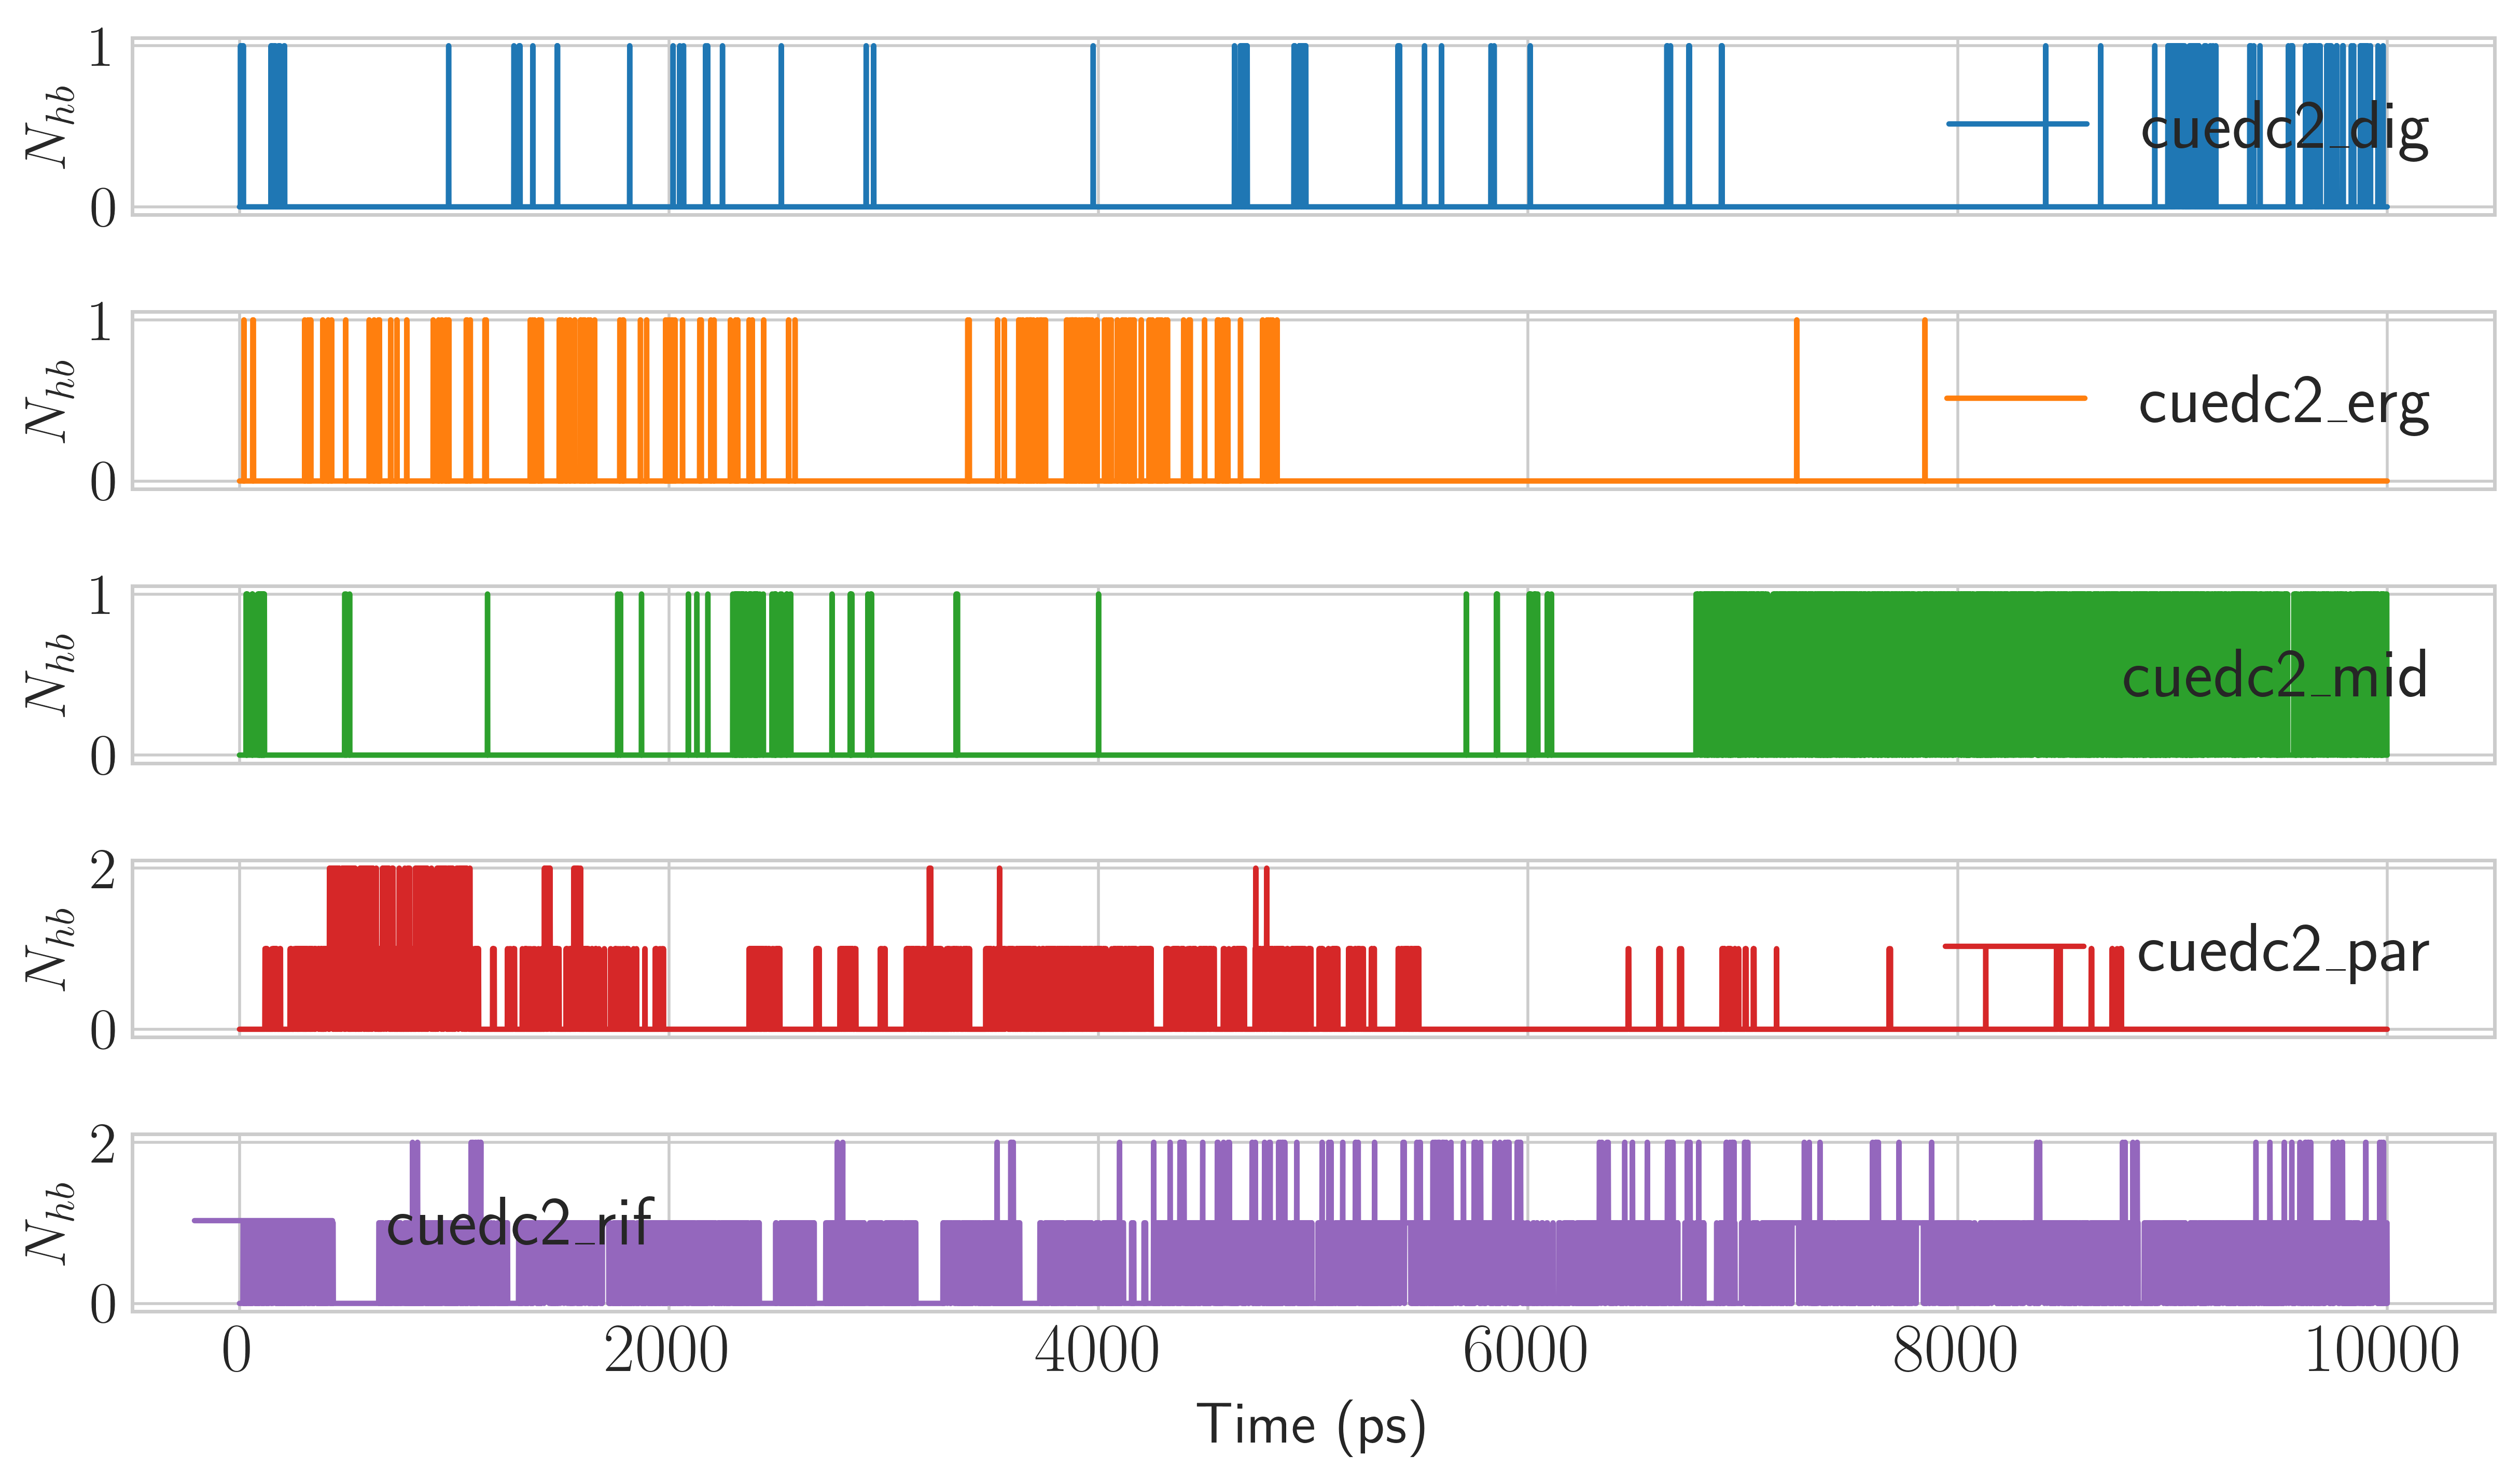

In [28]:

nhb_df.reindex(sorted(nhb_df.columns), axis=1).plot(
    subplots=True,
    layout=(5, 1),
    figsize=(10, 6),
    sharex=True,
    xlabel="Time (ps)",
    ylabel=r"$N_{hb}$"
);

### Detailed breakdown of hydrogen bond occupancies

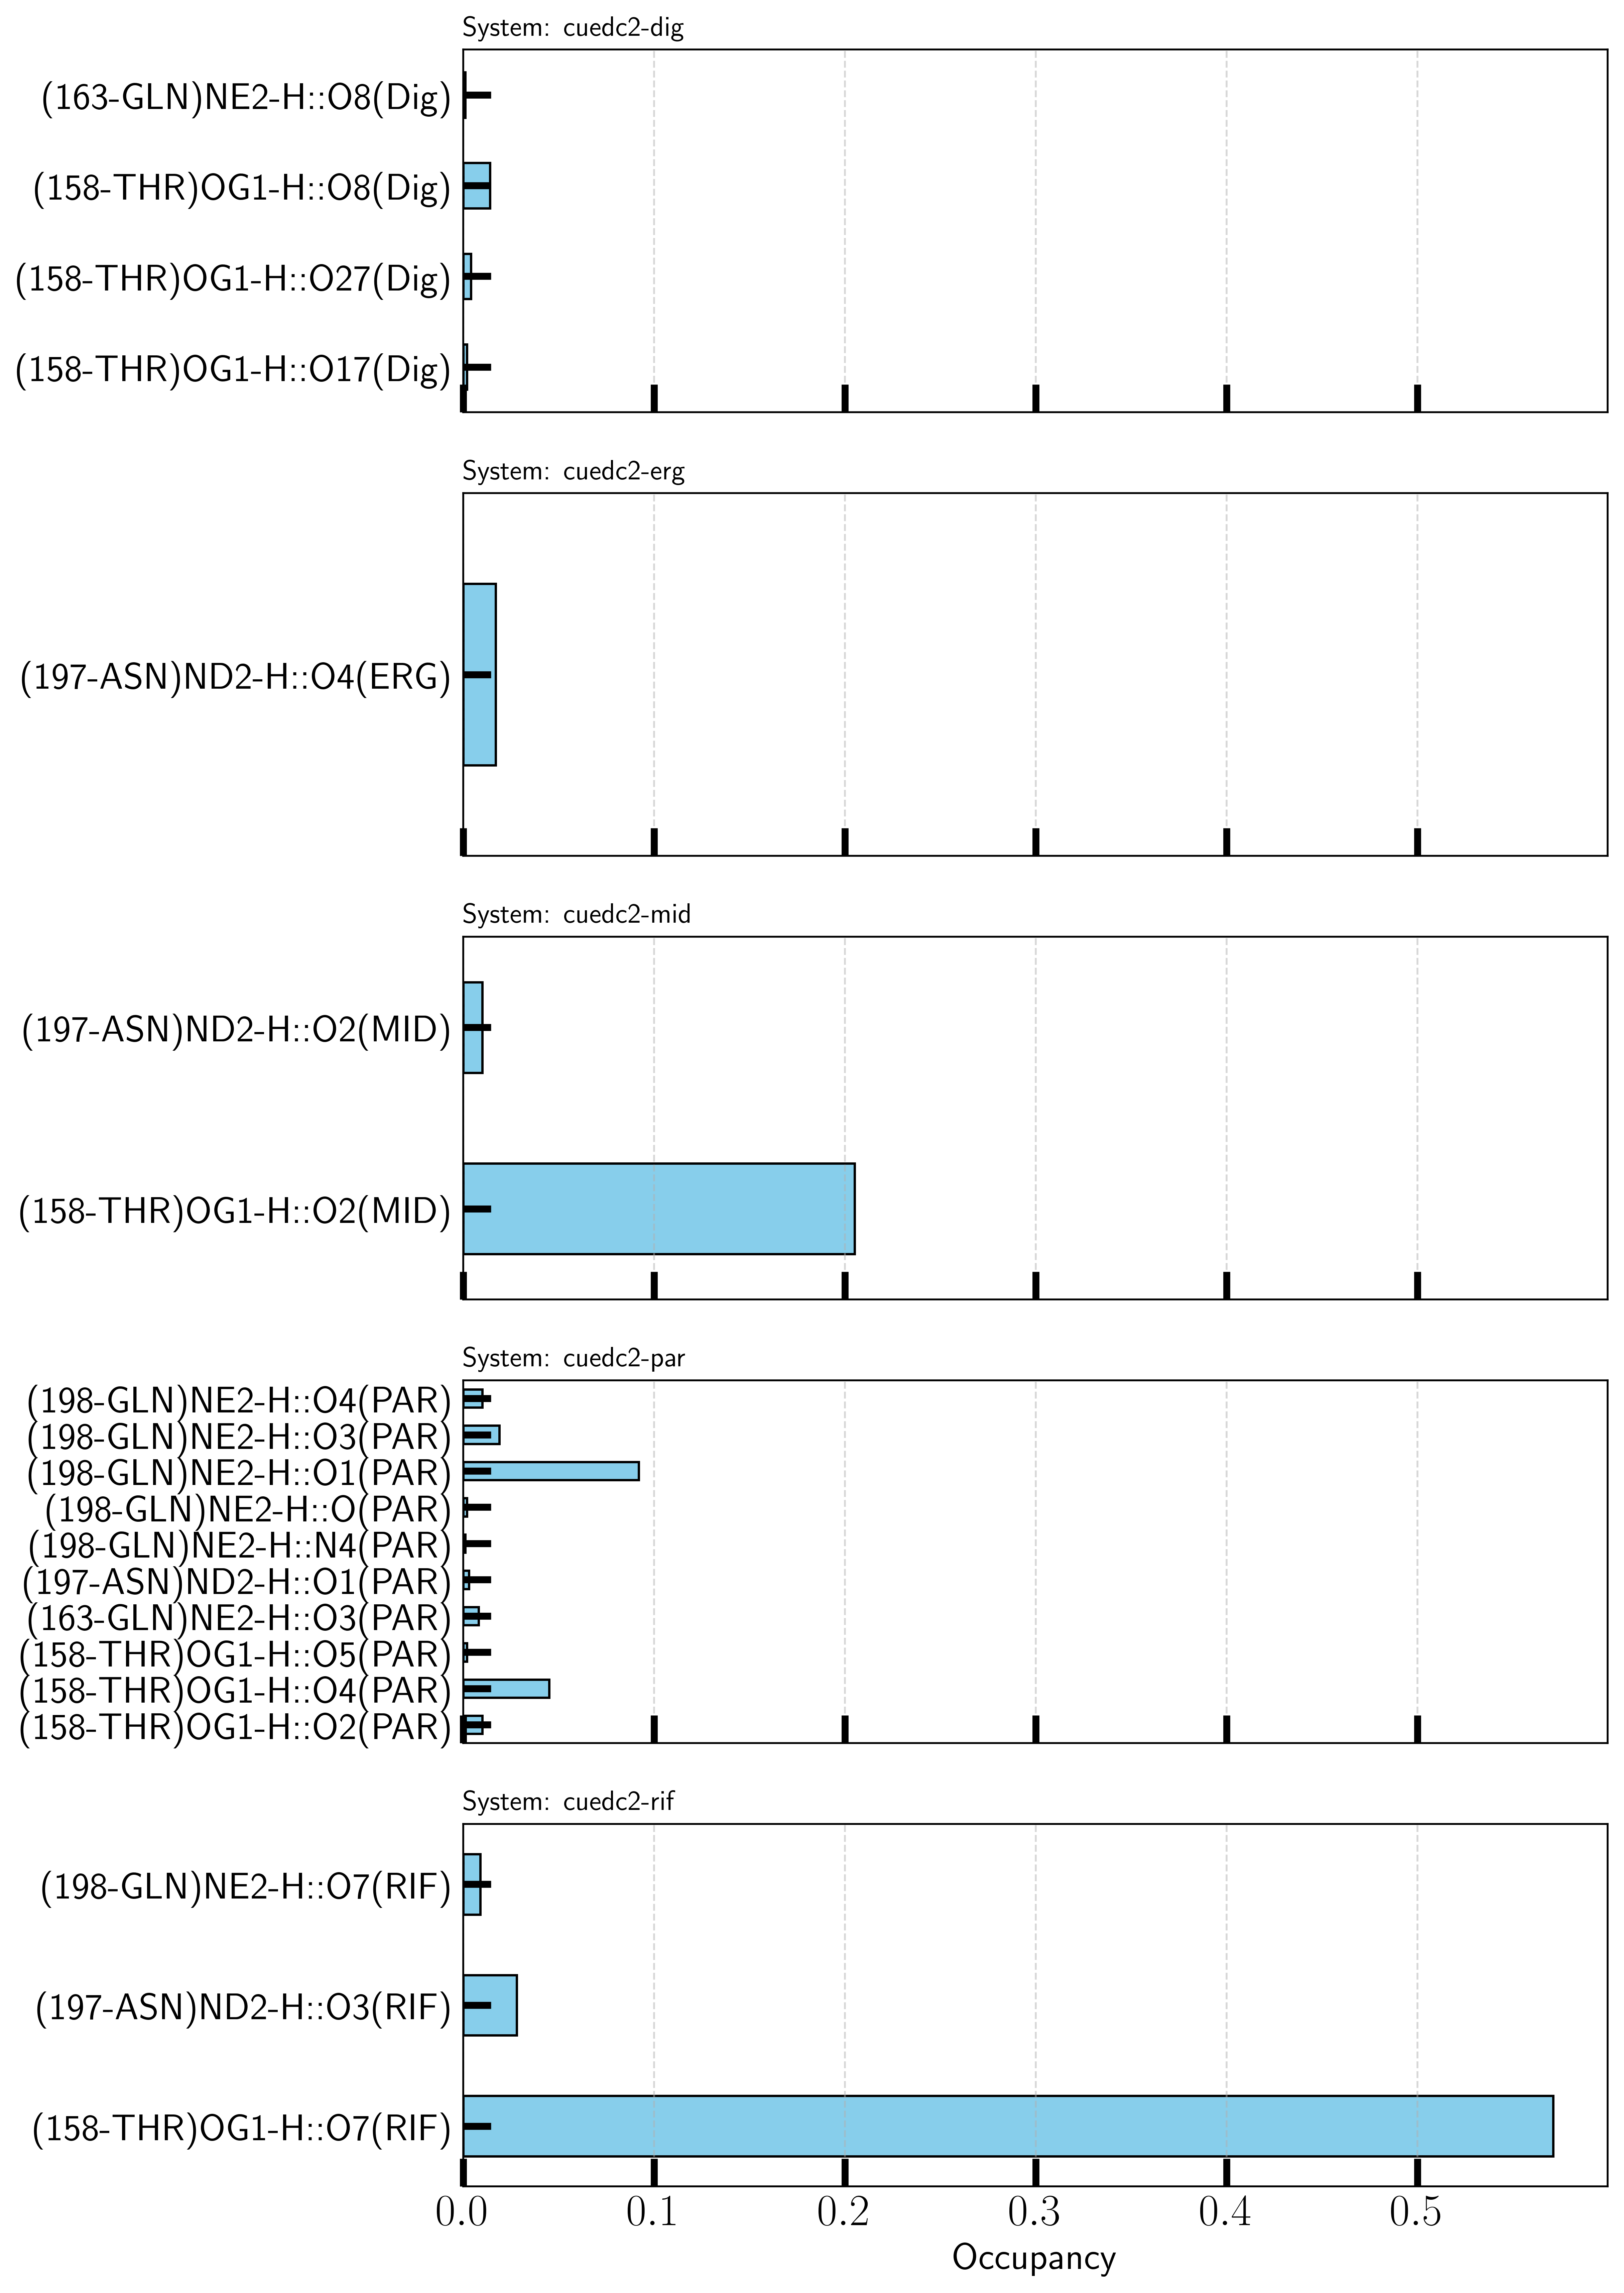

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Your raw dictionary data
data = hb_stats_data

# 2. Sort the main dictionary keys alphabetically
sorted_keys = sorted(data.keys())

# 3. Initialize a 5-row vertical subplots layout
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 14), sharex=True)

# 4. Process and plot each system onto its respective axis
for ax, key in zip(axes, sorted_keys):
    parsed_records = []

    for item in data[key]:
        # Split interaction text from occupancy float value
        interaction, occupancy = item.split(" : ")
        parsed_records.append(
            {"Interaction": interaction.strip(), "Occupancy": float(occupancy)}
        )

    # Convert to DataFrame and sum identical label entries if they exist
    df_plot = (
        pd.DataFrame(parsed_records)
        .groupby("Interaction")
        .sum()
        .reset_index()
    )

    # Plot horizontally (barh) so interaction strings remain readable on the y-axis
    df_plot.plot.barh(
        x="Interaction",
        y="Occupancy",
        ax=ax,
        color="skyblue",
        edgecolor="black",
        legend=False,
    )

    # Label styling details
    c_name = key.replace("_","-")
    ax.set_title(f"System: {c_name}", fontsize=12, fontweight="bold", loc="left")
    ax.set_ylabel("")  # Clear default pandas column label text
    ax.set_xlabel("Occupancy")
    ax.grid(axis="x", linestyle="--", alpha=0.5)

# Adjust layout to cleanly preserve long y-labels without truncation
plt.tight_layout()
plt.show()

## Tentative Conclusion

According to this data, Rifamycin is the clear winner at inhibiting CUEDC2, with a hydrogen bond occupancy of over 50% for the bond between (158THR)OG1 donor and O7 (RIF) acceptor. A distant second is Midostaurin, with a steady hydrogen bond between appearing between the same donor as the Rifamycin, with O2 (MID) as the acceptor. In all other cases, the hydrogen bonds become intermittent and distintegrate over time.